# Method Analysis

* VNeo method parsing adapted from from https://github.com/nickdelgrosso/XCaliburMethodReader/tree/master

## Imports

In [14]:
import olefile
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import os
import sys

%matplotlib inline

In [18]:
%load_ext autoreload
%autoreload 2

# Add parent directory to path to import modules from code/
sys.path.insert(0, os.path.abspath('..'))

from vneo_method import VNeoMethod
from lc_method_collection import VNeoMethodCollection
from ms_method import MicroTOFMethod
from ms_method_collection import MSMethodCollection
from anndiannloader import DiannLoader as dl
from diann_collection import DiannCollection

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load LC Methods

#### LC Collection Object

In [8]:
lccollection = VNeoMethodCollection()

In [9]:
lccollection.add_methods_from_folder('/Users/eileen.wang/Desktop/diann/SampleData/methods/LC')

/Users/eileen.wang/Desktop/diann/code/vneo_method.py:127: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gradient_df[col] = pd.to_numeric(gradient_df[col], errors='ignore')
/Users/eileen.wang/Desktop/diann/code/vneo_method.py:130: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  equil_df[col] = pd.to_numeric(equil_df[col], errors='ignore')


In [5]:
# lc_methods = '\n'.join(lccollection.methods.keys())
# print(f'Methods loaded: {len(lccollection.methods.keys())}\n{lc_methods}')

<Axes: title={'center': 'Gradient Comparison: 20m150nlv15, 23p75m150nlv16, 17p5m150nlv13, 36m150nlLong40, 25m150nlv5, 17p7m150nlv11, 25m200nlv5, 10m150nlRainmanA15-75, 20m150nlML23p5mA15v1, 25m150nlv4, 16m150nlv8, 23p75mHighACNWash150nlv17, 20p5m150nlv7, 20p5m150nlv6, 20m150nlML30mA15phospho4, 17p5m150nlv10, 20p5m150nlv14, 23p65m150nlv18Zebra, 11p5m150nlv9, 24m150nlThermo, 36m150nlSlow40, 27m150nlv3, 17p75m150nlv12, 20m150nlML30mA15v2'}, xlabel='time [min]', ylabel='Value [%]'>

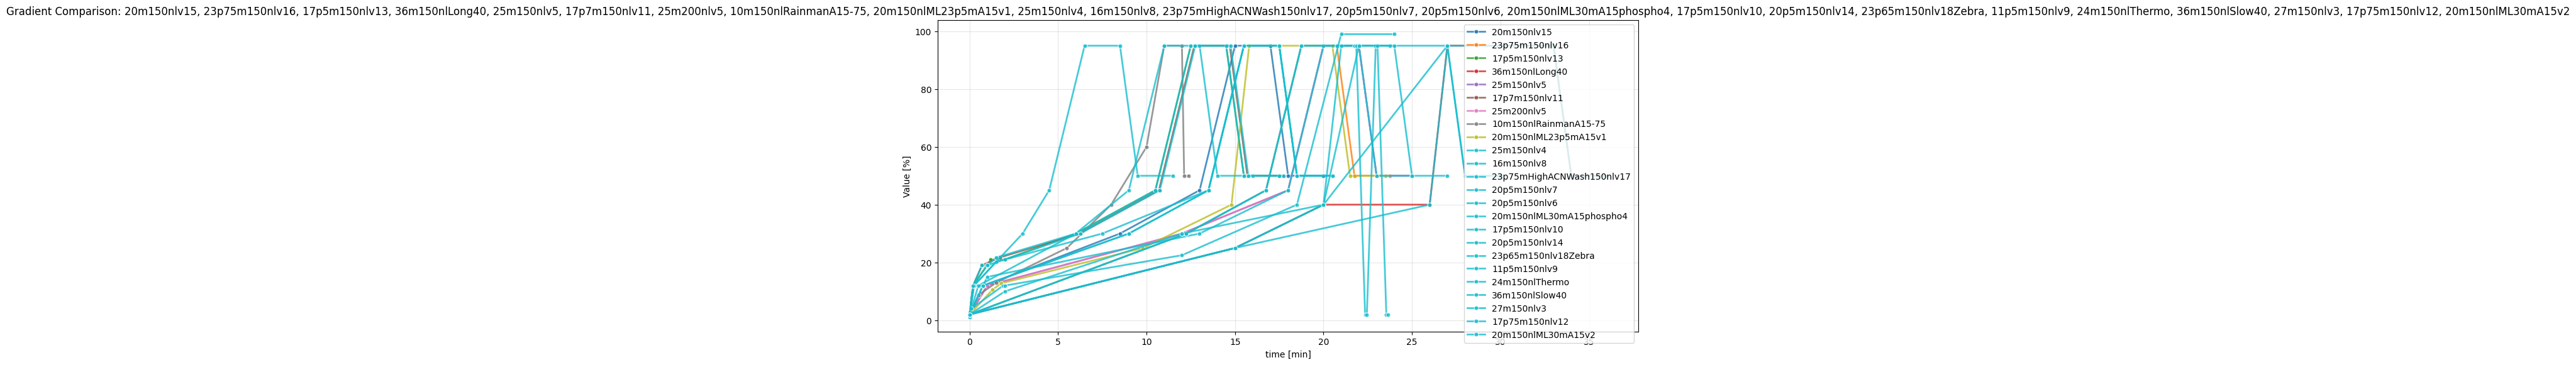

In [10]:
lccollection.plot_gradients(
                        x_col = 'time [min]',
                        y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'], 
                        twin_axes=True , 
                        markers=True
)

## MS Methods

### Load MS Methods

In [11]:
# Intialize MS method collector object
mscollection = MSMethodCollection()

In [12]:
# # Method 1: Add single method with explicit name
# collection.add_method("/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m")

# Method 2: Add from zip file (extracts and adds all methods inside)
mscollection.add_methods_from_folder("/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/260130_11AM.zip")
# collection.add_methods_from_paths(["/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m"], overwrite = 'ignore')
msmethod_names = '\n'.join(mscollection.methods.keys())
# print(f"Loaded {len(mscollection)} methods: {msmethod_names}")


### MS Meth Summary

In [849]:
# mscollection.summary_df()

### Find Differences between methods

In [954]:
method = mscollection['DIA011RT70expandedrange.proteoscape']
value = method['Collision_GasSupply_Set']  # Direct access!
# cap_voltage = method['default_Source_CapillarySetValue']  # Positive only
windows = method['dia_windows']  # Direct access!


In [964]:
df = mscollection.to_dataframe(
    method_names=['DIA007.proteoscape', 'DIA016.proteoscape'],  # Optional: subset methods
    # param_names=['Collision_GasSupply_Set', 'dia_window_count'],  # Optional: subset params
    exclude_dia_windows=True  # Exclude DataFrame objects by default
)

In [31]:
df = mscollection.to_dataframe()

In [49]:
## MS mass start/end
# df[['Mode_ScanBegin', 'Mode_ScanEnd']]

In [966]:
# finding differences between 2+ methods
diff = mscollection.find_differences(['DIA011RT60.proteoscape','DIA018.proteoscape'])
diff

,Parameter,Type,Description,DIA011RT60.proteoscape,DIA018.proteoscape
0,Vacuum_LastCapillaryCleaningDate,instrument_param,,2025-11-24T12:05:17-08:00,2025-08-18T09:57:05-07:00
1,TOF_DetectorTofSetValue,instrument_param,,2265.0,2252.0
2,default_IMS_Calibration_RampVelocity_Save,polarity_param,positive polarity,0.205078,0.427318
3,default_IMS_Calibration_LastCalibrationDate,polarity_param,positive polarity,2025-09-10T17:35:19-07:00,2025-09-11T11:46:42-07:00
4,default_IMS_CalibrationRampEnd,polarity_param,positive polarity,139.972162,140.502687
5,default_IMS_Calibration_LastCalibrationMassInt...,polarity_param,positive polarity,"[1445930.0230822468, 1471710.2676116882, 75735...","[787028.996186168, 1230470.924191452, 177976.4..."
6,default_IMS_Calibration_Funnel1In_Pressure,polarity_param,positive polarity,2.387,2.403
7,default_IMS_CalibrationCoefficients,polarity_param,positive polarity,"[0.03084927968991898, 160.35509090775577, 15.9...","[0.001523152265349233, 165.08327143248422, 16...."
8,default_IMS_CalibrationRampStart,polarity_param,positive polarity,243.402636,239.900581
9,default_IMS_Calibration_StdDev,polarity_param,positive polarity,0.000138,0.000599


#### Plotting differences

No numeric parameters found to plot


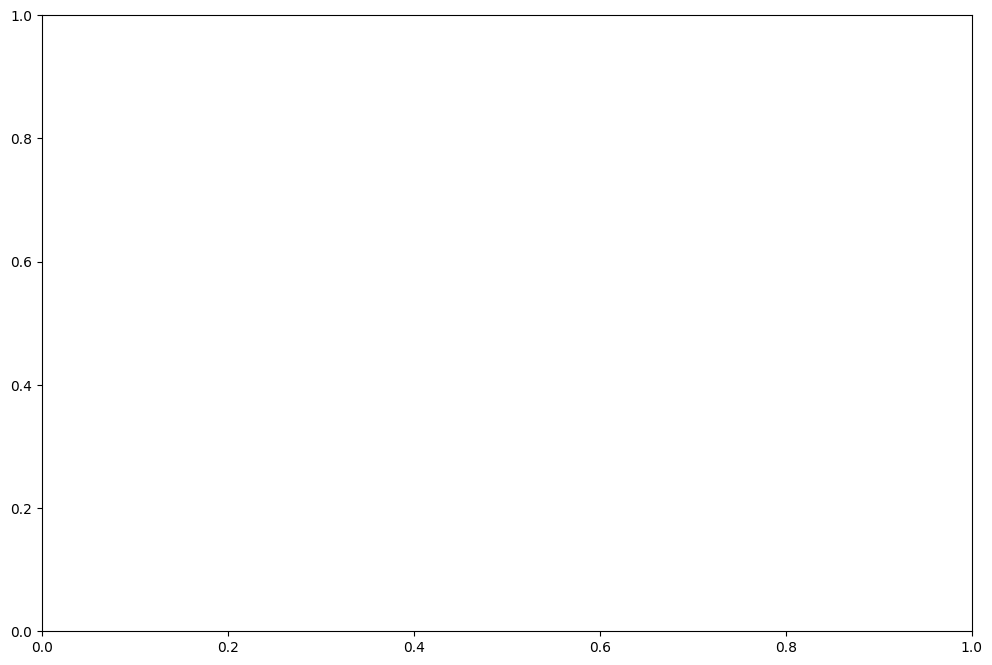

In [971]:
mscollection.plot_differences(method_names = ['DIA011RT60.proteoscape',
'DIA018.proteoscape',
'DIA011RT60.proteoscape',
'DIA018.proteoscape',
'DIA011QC2v1600.proteoscape'],
)

### Plot DIA Windows

<Axes: title={'center': 'DIA Windows Overlay: DIA011RT60.proteoscape, DIA018.proteoscape'}, xlabel='m/z', ylabel='1/K0 (Ion Mobility)'>

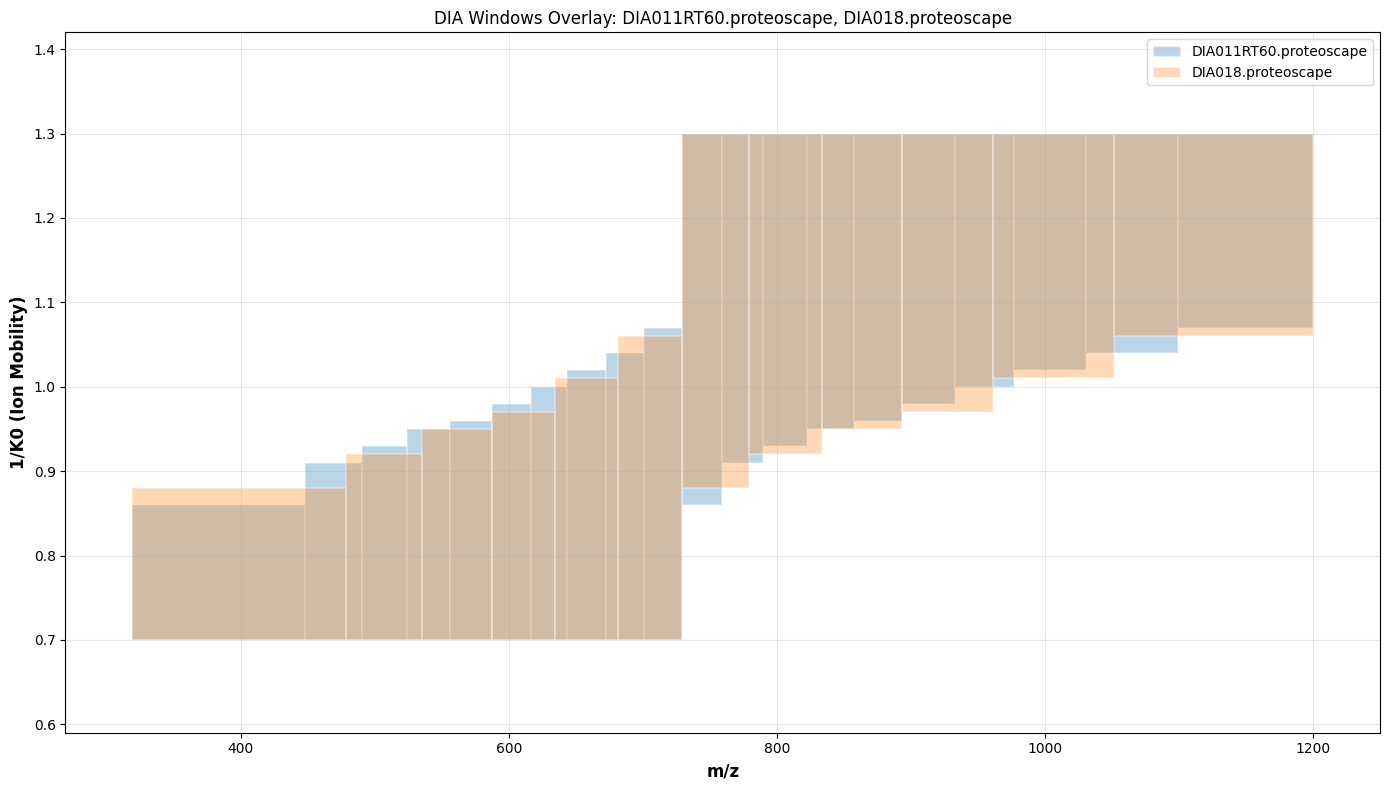

In [902]:
mscollection.plot_windows(['DIA011RT60.proteoscape', 'DIA018.proteoscape'], color_by_method=True,
                    alpha=0.3,
                    # edge_color='white',
                    # figsize=(14, 8),
                    show_labels=False)

## Loading Searches

### BPS

In [24]:
bpscollection = DiannCollection(log_file = '/Users/eileen.wang/Desktop/diann/log/sample_collection_log.txt')

In [25]:
for i in ['5bb65d07aa6a2f77f81b5e08ab034d2b', 
          # '91e1fd4b7eb0d9bcc1efe2d697ec6237',
          # '4032c8c9eb896d865ede0acf6854adbd',
          # 'e086878c8a63cdb635efbfdfc701b60b'
         ]:

    bpscollection.add_from_folder(f"/Users/eileen.wang/Desktop/diann/SampleData/BPS/{i}.zip", levels=["precursor", "protein"])

### Fragpipe

In [50]:
fpcollection = DiannCollection()

In [51]:
fpcollection.add_single_search("/Users/eileen.wang/Desktop/diann/SampleData/FP/FP_100pg20ng_25m/report.tsv", search_type='fragpipe', levels=['precursor', 'protein'])

Loading from direct .tsv file: report.tsv

Loading report from report.tsv...
  ⚠ Note: precursor level missing some columns: Corr.Precursor.Error.Ppm, Corrected.Precursor.Mz, Data.Points...
  Loading precursor level...
    ✓ precursor: (79173, 10)
  Loading protein level...
    ✓ protein: (6412, 10)

Adding to collection...
  Adding precursor level...
    ✓ Added precursor with shape: (79173, 10)
  Adding protein level...
    ✓ Added protein with shape: (6412, 10)

✓ Added sample 'report' to collection


In [55]:
fpcollection['precursor']

AnnData object with n_obs × n_vars = 79173 × 10
    obs: 'Precursor.Id', 'Modified.Sequence', 'Stripped.Sequence', 'Precursor.Charge', 'Protein.Group', 'Protein.Ids', 'Protein.Names', 'Genes', 'All Mapped Proteins', 'All Mapped Genes', 'Lib.Index'
    var: 'File.Name'
    layers: 'Precursor.Quantity', 'Precursor.Normalised', 'IM', 'iIM', 'Predicted.IM', 'Predicted.iIM', 'Precursor.Mz', 'Proteotypic', 'iRT', 'Predicted.RT', 'Predicted.iRT', 'Q.Value', 'PEP', 'Global.Q.Value', 'Translated.Q.Value', 'Precursor.Translated', 'Translated.Quality', 'Ms1.Translated', 'Quantity.Quality', 'RT', 'RT.Start', 'RT.Stop', 'Lib.Q.Value', 'Ms1.Profile.Corr', 'Ms1.Area', 'Evidence', 'Spectrum.Similarity', 'Averagine', 'Mass.Evidence', 'CScore', 'Decoy.Evidence', 'Decoy.CScore', 'Fragment.Quant.Raw', 'Fragment.Quant.Corrected', 'Fragment.Correlations', 'MS2.Scan', 'Fragment.Info'

In [ ]:
                                
    # Access data
    # adata = collection['sample1', 'precursor']
    # print(f"Shape: {adata.shape}")
    
    # Summary
    # summary = collection.summary_df()
    # print(summary)
    
#     # Save
#     collection.save("my_collection.pkl")

# # Load later
# collection = DiannCollection.from_file("my_collection.pkl")


## Combine Sample and Method

/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


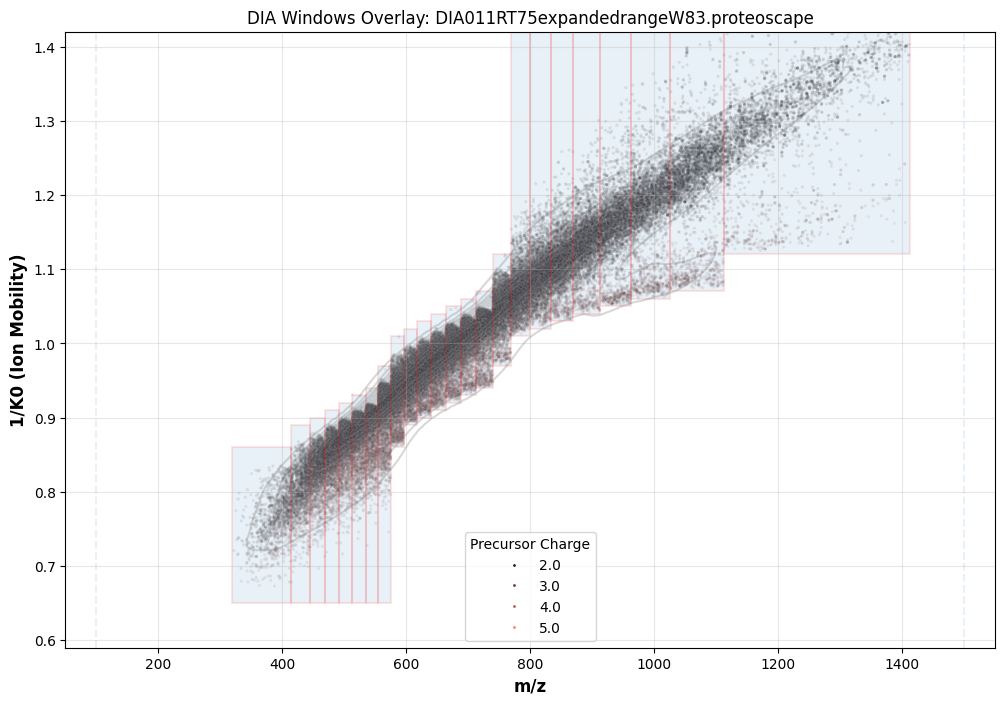

In [77]:
fig, ax = plt.subplots(figsize=(12, 8))
adata = samplecollection.data['precursor']
sample = adata[:, 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p75m150nlv12_DIA75msW83_TT0000219_B-B1_1_14620']

# 1. Plot DIA windows first (m/z × IM space)


# Scatter plot of precursors
sns.scatterplot(
    x = sample.layers['Precursor.Calibrated.Mz'][:, 0], 
    y = sample.layers['Exp.1/K0'][:, 0],
    hue = sample.obs['Precursor.Charge'].values,
    palette=sns.color_palette("dark:salmon", as_cmap=True),
    s=5, 
    alpha=0.1,
    ax=ax)



mscollection.plot_windows(['DIA011RT75expandedrangeW83.proteoscape'], 
                          color_by_method=True,
                          alpha=0.1,
                          show_labels=False,
                          edge_color ='red',
                          ax=ax)

sns.kdeplot(x = sample.layers['Precursor.Calibrated.Mz'].flatten(), 
           y = sample.layers['Exp.1/K0'].flatten(),
           s=1, 
           alpha=0.3, 
           color='grey',
           ax=ax)

ax.legend(title='Precursor Charge')

legend = ax.legend_
for lh in legend.legend_handles:
    lh.set_alpha(1) # Set alpha to 1 (fully opaque)
    lh._sizes = [250]

# plt.tight_layout()


#### Ion Mobility Errir

(-0.2, 0.2)

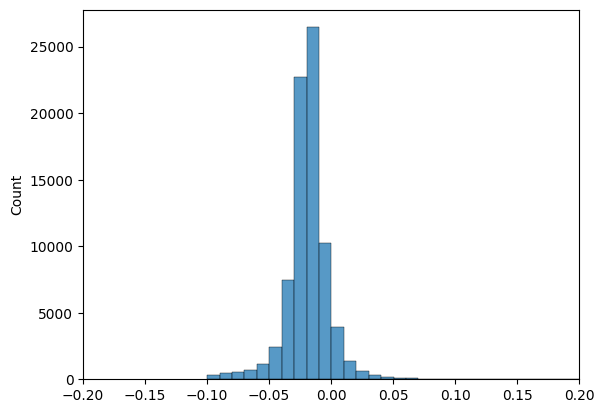

In [66]:
sns.histplot((sample.layers['Lib.1/K0'] - sample.layers['Exp.1/K0']).flatten(), binwidth =0.01)
plt.xlim(-0.2, 0.2)

/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


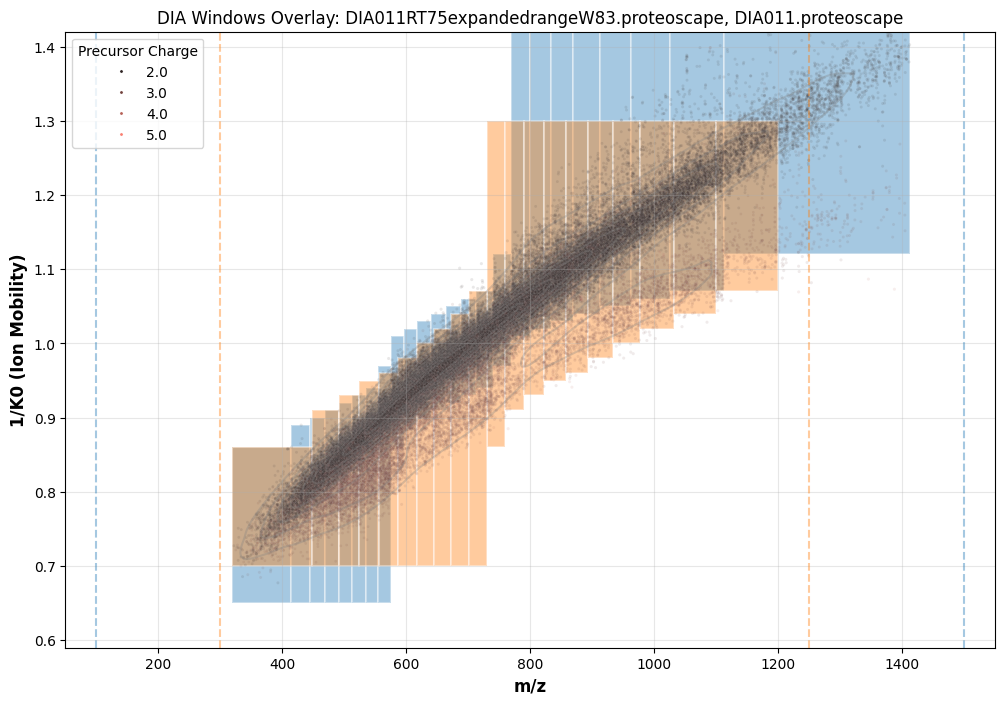

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
adata = samplecollection.data['precursor']
sample = adata[:, 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p75m150nlv12_DIA75msW83_TT0000219_B-B1_1_14620']

# 1. Plot DIA windows first (m/z × IM space)
sns.kdeplot(x = sample.layers['Precursor.Calibrated.Mz'].flatten(), 
           y = sample.layers['Lib.1/K0'].flatten(),
           s=1, 
           alpha=0.3, 
           color='grey',
           ax=ax)

mscollection.plot_windows(['DIA011RT75expandedrangeW83.proteoscape', 'DIA011.proteoscape'], 
                          color_by_method=True,
                          alpha=0.4,
                          show_labels=False, 
                          ax=ax)

# Scatter plot of precursors
sns.scatterplot(
    x = sample.layers['Precursor.Calibrated.Mz'][:, 0], 
    y = sample.layers['Lib.1/K0'][:, 0],
    hue = sample.obs['Precursor.Charge'].values,
    palette=sns.color_palette("dark:salmon", as_cmap=True),
    s=5, 
    alpha=0.1,
    ax=ax)

ax.legend(title='Precursor Charge')

legend = ax.legend_
for lh in legend.legend_handles:
    lh.set_alpha(1) # Set alpha to 1 (fully opaque)
    lh._sizes = [250

# plt.tight_layout()


## Matching Methods to Samples

In [70]:
df = pd.read_csv('/Users/eileen.wang/Desktop/diann/SampleData/Sequences/2026_01_lcmsmethodmapping.csv')

In [204]:
def plot_precursor_mz_im(adata, s, mscollection, ms_method='sample', mz ='Precursor.Calibrated.Mz', im='Exp.1/K0'):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    sample = adata[:, s]

    # 1. Plot DIA windows first (m/z × IM space)
    sns.kdeplot(x = sample.layers[mz].flatten(), 
            y = sample.layers[im].flatten(),
            s=1, 
            alpha=0.3, 
            color='grey',
            ax=ax)

    if ms_method == 'sample':
        meth = adata.var.loc[s, 'MSmeth']
        mscollection.plot_windows([meth], 
                                color_by_method=True,
                                alpha=0.4,
                                show_labels=False, 
                                ax=ax)

    # Scatter plot of precursors
    sns.scatterplot(
        x = sample.layers[mz][:, 0], 
        y = sample.layers[im][:, 0],
        hue = sample.obs['Precursor.Charge'].values,
        palette=sns.color_palette("dark:salmon", as_cmap=True),
        s=5, 
        alpha=0.1,
        ax=ax)

    ax.legend(title='Precursor Charge')

    legend = ax.legend_
    for lh in legend.legend_handles:
        lh.set_alpha(1) # Set alpha to 1 (fully opaque)
        lh._sizes = [250]

    # plt.tight_layout()


In [224]:
test.var['hystar_idx'] = test.var['File.Name'].str.extract('.+_(\d+)$')

/var/folders/fw/_hz2f4mj6pdc3ffplz4b82lc0000gq/T/ipykernel_22839/853797646.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  test.var['hystar_idx'] = test.var['File.Name'].str.extract('.+_(\d+)$')


In [40]:
# test.var.sort_values('hystar_idx')

In [240]:
test.var_names[test.var['hystar_idx']=='14584']

Index(['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20min_DIA003_TT0000182_B-B11_1_14584'], dtype='object', name='File.Name')

/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


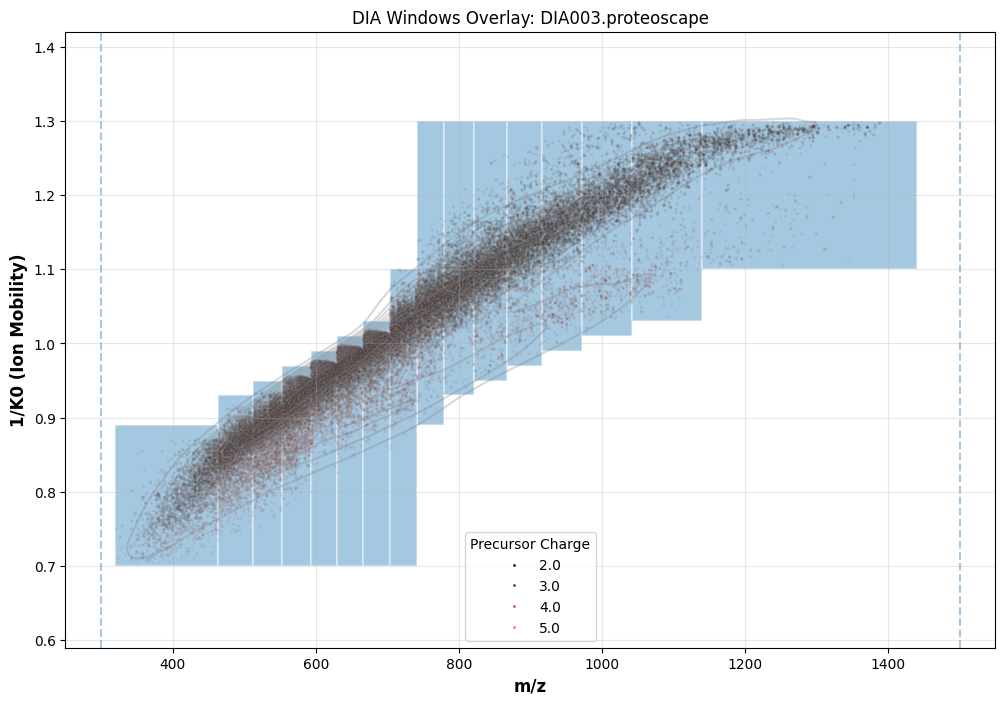

In [241]:
plot_precursor_mz_im(test, 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20min_DIA003_TT0000182_B-B11_1_14584', mscollection)

# Analyzing Methods

1. How many precursors are being collected/detected per cycle?
2. How many precusors are being collected per unit time?
3. What percentage of precursors do our DIA windows collect?
   * Which precursors does it leave out?
   * Evaluating window size vs precursors actually in a window per unit time? 
4. What is the difference in number of precursors detected per sample/run?
   * How do they plot in terms of RT, IM, MZ, etc
5. Carryover?
   * % of total intensity 
   * % vs intensity in previous sample
   * properties of carrover/distribution vs RT